# Лабораторна робота №2
## Фільтрація, покращення та сегментація зображень
Мета: дослідити ефективність просторових методів фільтрації та покращення зображень.

### Основні завдання
Дослідити:  
• Gaussian filter;  
• Median filter;  
• Bilateral filter;  
• Histogram Equalization;  

• CLAHE;  
• Otsu;  
• Adaptive Thresholding.  

### Дослідницька складова
Сформувати три рівні шуму:  

σ ∈ {0.05, 0.1, 0.2}  
Для кожного шуму застосувати декілька фільтрів.  
Порівняти: MSE, PSNR, SSIM.  
Побудувати: PSNR = f(σ)  

### Дослідницькі питання  
• Який фільтр найкраще усуває Gaussian noise?  
• Який метод ефективніший для salt-and-pepper noise?  
• Як збільшення розміру ядра впливає на деталізацію?  
• Чи завжди підвищення PSNR означає покращення візуальної якості?  
Міні-дослідження: визначити оптимальні параметри фільтра автоматично.  
#### Результат: *зображення-приклади, таблиці експериментів, графіки та обґрунтований висновок*.  
---

### Завантажуємо зображення (те саме, що і в ЛР №1)

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

file_name = "puppy.bmp"
image_bgr = cv2.imread(file_name, cv2.IMREAD_COLOR)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

height, width = image_rgb.shape[:2]

## 1. Створення зображень із шумом
Два типи шуму: гаусів (адитивний, σ = 0.1) та імпульсний "сіль і перець" (d = 5%).  
Результати зберігаємо у файли `puppy_gaussian_noise.png` та `puppy_salt_pepper_noise.png`.

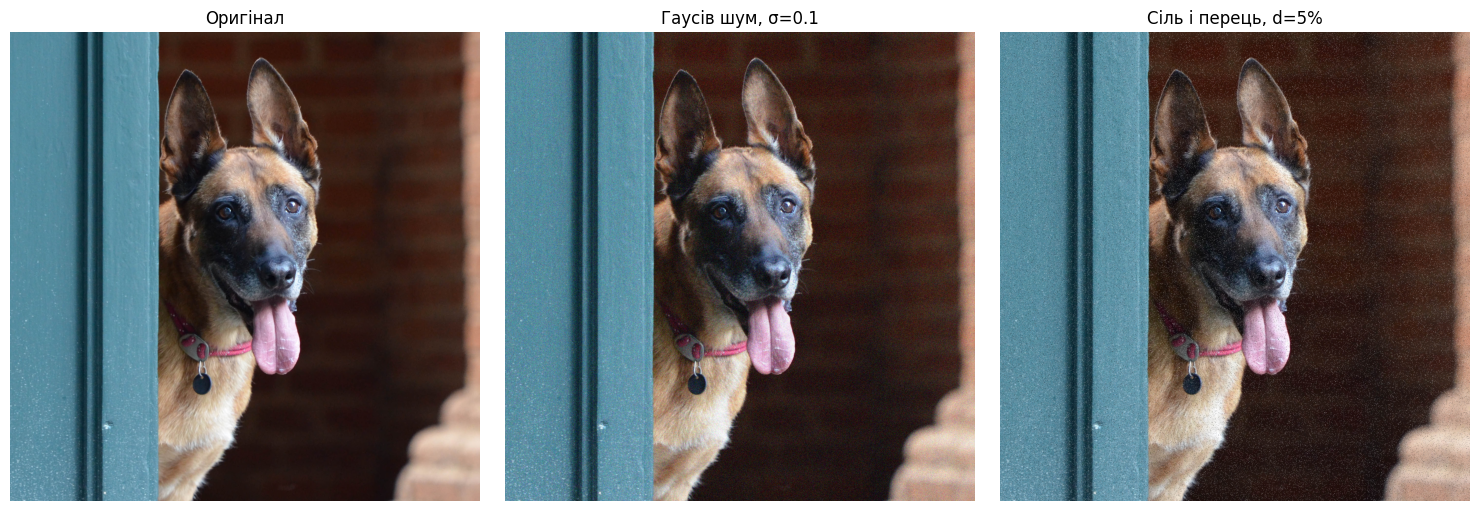

In [2]:
def add_gaussian_noise(image, sigma):
    """Додає адитивний гаусів шум. sigma задається в частках від 255 (діапазон [0, 1])."""
    image_norm = image.astype(np.float64) / 255.0
    noise = np.random.normal(loc=0.0, scale=sigma, size=image.shape)
    noisy = np.clip(image_norm + noise, 0.0, 1.0)
    return (noisy * 255).astype(np.uint8)


def add_salt_pepper_noise(image, d):
    """Додає імпульсний шум "сіль і перець". d - сумарна частка уражених пікселів [0, 1]."""
    noisy = image.copy()
    mask = np.random.random(image.shape[:2])

    salt_mask = mask < d / 2
    pepper_mask = (mask >= d / 2) & (mask < d)

    noisy[salt_mask] = 255
    noisy[pepper_mask] = 0

    return noisy


np.random.seed(42)

sigma = 0.1
d = 0.05

gaussian_noisy = add_gaussian_noise(image_rgb, sigma)
salt_pepper_noisy = add_salt_pepper_noise(image_rgb, d)

# Збереження результатів
cv2.imwrite("puppy_gaussian_noise.png", cv2.cvtColor(gaussian_noisy, cv2.COLOR_RGB2BGR))
cv2.imwrite("puppy_salt_pepper_noise.png", cv2.cvtColor(salt_pepper_noisy, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Оригінал")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gaussian_noisy)
plt.title(f"Гаусів шум, σ={sigma}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(salt_pepper_noisy)
plt.title(f"Сіль і перець, d={int(d*100)}%")
plt.axis("off")

plt.tight_layout()
plt.show()

## 2. Дослідження фільтрів
Порівнюємо, який фільтр найкраще підходить під свій тип шуму:
Gaussian і Bilateral — для гаусового шуму; Median — для "сіль і перець".
Окремо перевіряємо, як Median відпрацьовує на гаусовому шумі (для якого він не є основним інструментом).

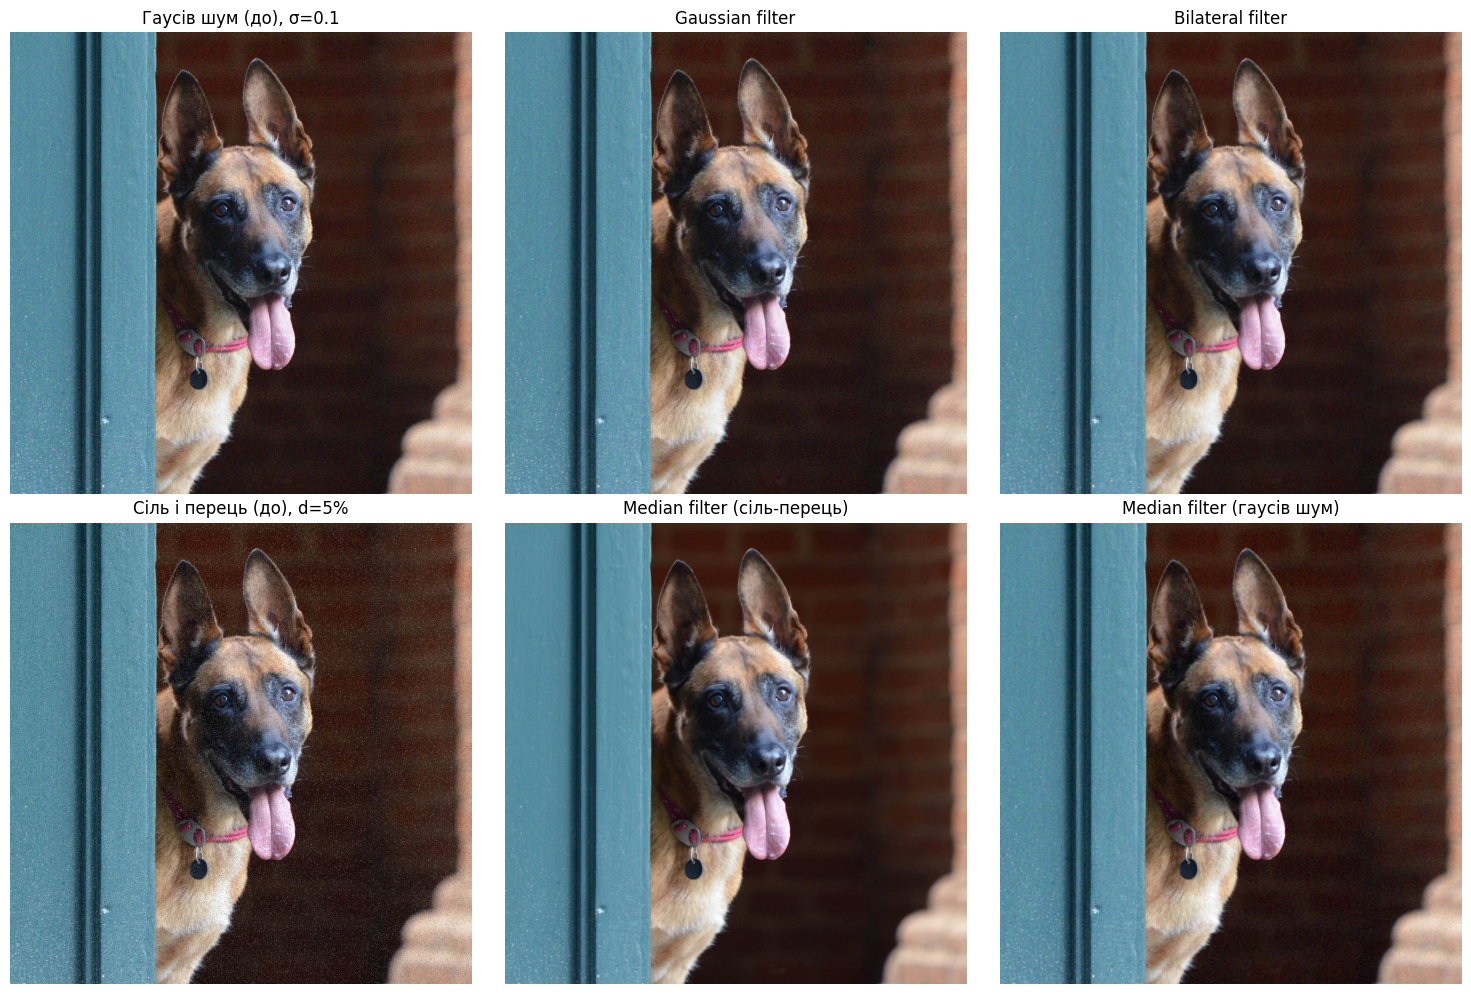

In [3]:
gaussian_filtered = cv2.GaussianBlur(gaussian_noisy, (5, 5), sigmaX=0)
bilateral_filtered = cv2.bilateralFilter(gaussian_noisy, d=9, sigmaColor=75, sigmaSpace=75)

median_filtered_sp = cv2.medianBlur(salt_pepper_noisy, 5)
median_filtered_gauss = cv2.medianBlur(gaussian_noisy, 5)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(gaussian_noisy)
plt.title(f"Гаусів шум (до), σ={sigma}")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gaussian_filtered)
plt.title("Gaussian filter")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(bilateral_filtered)
plt.title("Bilateral filter")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(salt_pepper_noisy)
plt.title(f"Сіль і перець (до), d={int(d*100)}%")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(median_filtered_sp)
plt.title("Median filter (сіль-перець)")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(median_filtered_gauss)
plt.title("Median filter (гаусів шум)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
images_for_psnr = {
    "Гаусів шум (до)": gaussian_noisy,
    "Gaussian filter": gaussian_filtered,
    "Bilateral filter": bilateral_filtered,
    "Сіль і перець (до)": salt_pepper_noisy,
    "Median filter (сіль-перець)": median_filtered_sp,
    "Median filter (гаусів шум)": median_filtered_gauss,
}

print("PSNR відносно оригіналу:\n")
print(f"{'Зображення':<32}{'PSNR, дБ':<12}")
print("-" * 44)

for name, img in images_for_psnr.items():
    psnr = peak_signal_noise_ratio(image_rgb, img, data_range=255)
    print(f"{name:<32}{psnr:<12.2f}")

PSNR відносно оригіналу:

Зображення                      PSNR, дБ    
--------------------------------------------
Гаусів шум (до)                 20.50       
Gaussian filter                 31.16       
Bilateral filter                31.11       
Сіль і перець (до)              17.79       
Median filter (сіль-перець)     39.63       
Median filter (гаусів шум)      31.22       


## 3. Покращення контрасту: Histogram Equalization vs CLAHE
Класична еквалізація гістограми діє глобально й може перепідсилити контраст там, де він і без того нормальний.
CLAHE діє локально (по плитках) з обмеженням контрасту, тому зберігає деталі краще.

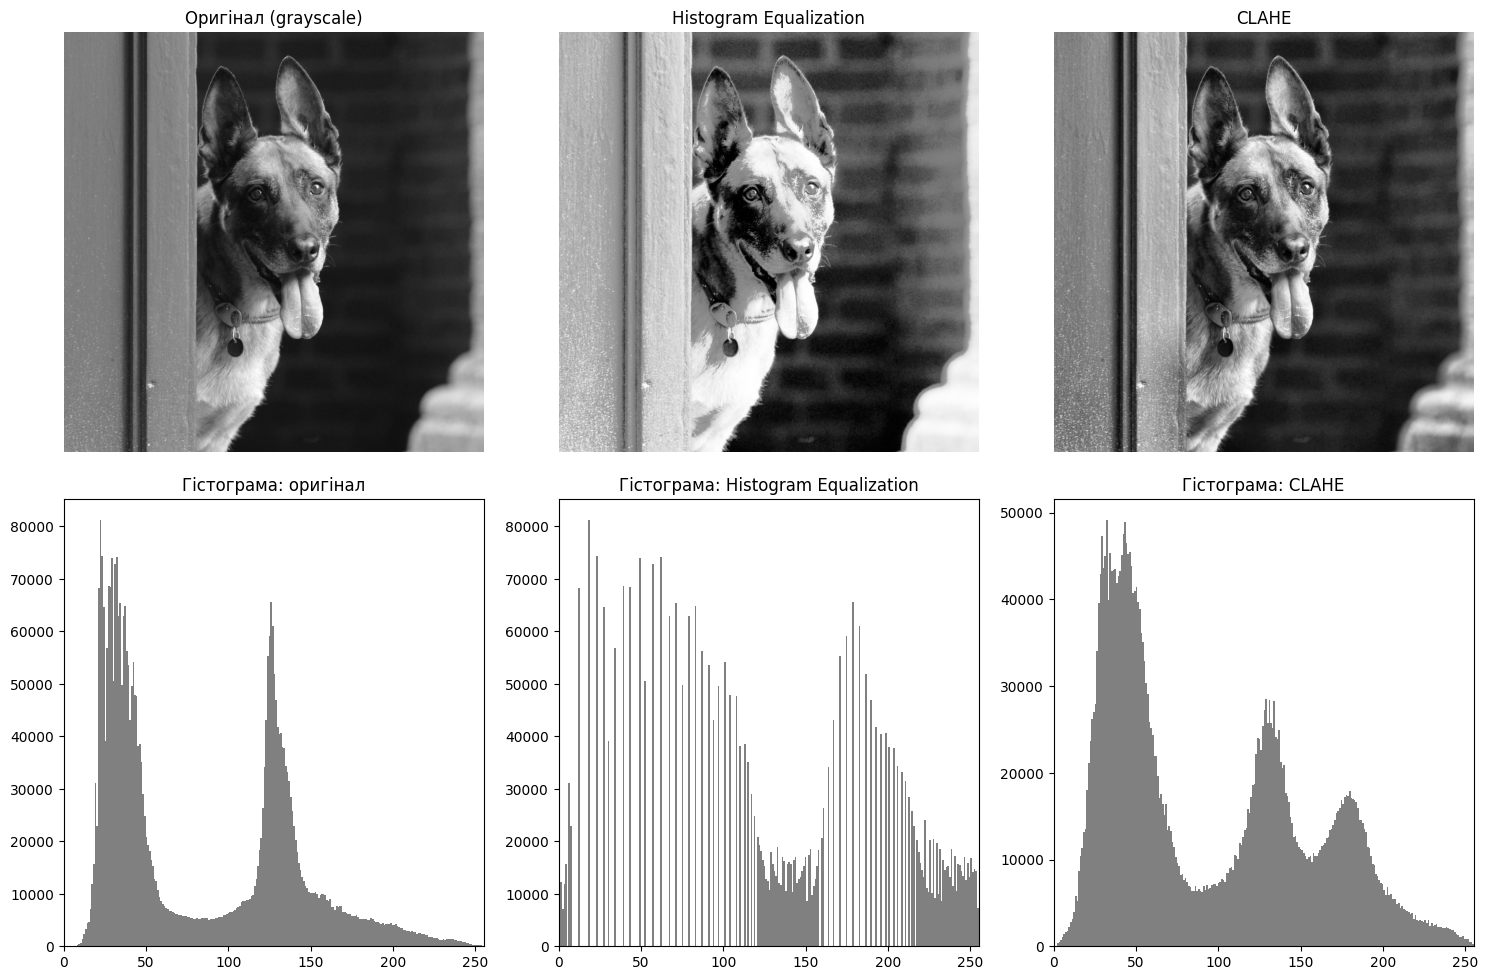

In [5]:
hist_eq = cv2.equalizeHist(image_gray)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(image_gray)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Оригінал (grayscale)")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(hist_eq, cmap="gray", vmin=0, vmax=255)
plt.title("Histogram Equalization")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(clahe_img, cmap="gray", vmin=0, vmax=255)
plt.title("CLAHE")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.hist(image_gray.ravel(), bins=256, range=(0, 255), color="gray")
plt.title("Гістограма: оригінал")
plt.xlim(0, 255)

plt.subplot(2, 3, 5)
plt.hist(hist_eq.ravel(), bins=256, range=(0, 255), color="gray")
plt.title("Гістограма: Histogram Equalization")
plt.xlim(0, 255)

plt.subplot(2, 3, 6)
plt.hist(clahe_img.ravel(), bins=256, range=(0, 255), color="gray")
plt.title("Гістограма: CLAHE")
plt.xlim(0, 255)

plt.tight_layout()
plt.show()

## 4. Бінаризація: Otsu vs Adaptive Thresholding
Otsu шукає один поріг для всього зображення — добре працює при рівномірному освітленні.
Adaptive Thresholding обчислює поріг локально для кожної області — рятує ситуацію, коли освітлення нерівномірне.
Оскільки оригінальне фото знято за рівномірного освітлення, нерівномірне освітлення змодельовано штучно (лінійний градієнт яскравості).

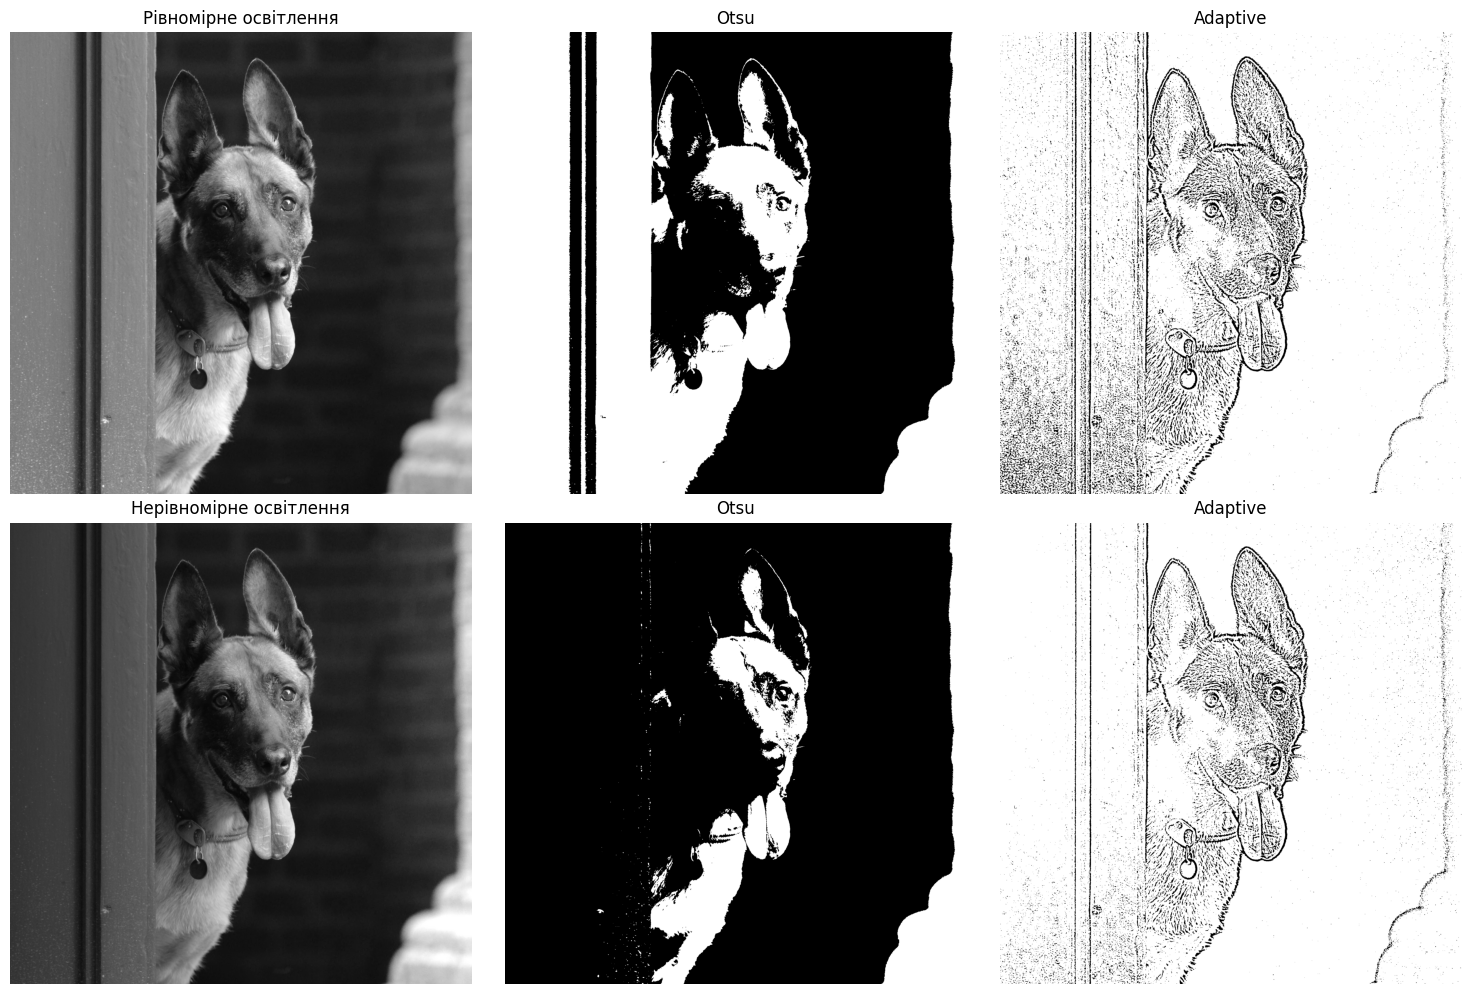

In [6]:
uniform_gray = image_gray

# Синтетичне нерівномірне освітлення (лінійний градієнт зліва направо)
gradient = np.tile(np.linspace(0.4, 1.3, width), (height, 1))
uneven_gray = np.clip(uniform_gray.astype(np.float64) * gradient, 0, 255).astype(np.uint8)

# Otsu
_, otsu_uniform = cv2.threshold(uniform_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, otsu_uneven = cv2.threshold(uneven_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Adaptive Thresholding
adaptive_uniform = cv2.adaptiveThreshold(
    uniform_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=25, C=5
)
adaptive_uneven = cv2.adaptiveThreshold(
    uneven_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=25, C=5
)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(uniform_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Рівномірне освітлення")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(otsu_uniform, cmap="gray")
plt.title("Otsu")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(adaptive_uniform, cmap="gray")
plt.title("Adaptive")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(uneven_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Нерівномірне освітлення")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(otsu_uneven, cmap="gray")
plt.title("Otsu")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(adaptive_uneven, cmap="gray")
plt.title("Adaptive")
plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Дослідницький експеримент
Досліджуємо залежність PSNR і SSIM від рівня шуму для обох типів шуму та чотирьох варіантів обробки
(без фільтра, Gaussian, Median, Bilateral):
σ ∈ {0.05, 0.1, 0.2} — гаусів шум, d ∈ {0.02, 0.05, 0.1} — "сіль і перець".

In [7]:
def apply_filter(name, noisy_image):
    if name == "без фільтра":
        return noisy_image
    if name == "Gaussian":
        return cv2.GaussianBlur(noisy_image, (5, 5), sigmaX=0)
    if name == "Median":
        return cv2.medianBlur(noisy_image, 5)
    if name == "Bilateral":
        return cv2.bilateralFilter(noisy_image, d=9, sigmaColor=75, sigmaSpace=75)
    raise ValueError(name)


filters = ["без фільтра", "Gaussian", "Median", "Bilateral"]
sigma_levels = [0.05, 0.1, 0.2]
d_levels = [0.02, 0.05, 0.1]

np.random.seed(42)
research_results = []

for level in sigma_levels:
    noisy = add_gaussian_noise(image_rgb, level)
    for filt in filters:
        result = apply_filter(filt, noisy)
        psnr = peak_signal_noise_ratio(image_rgb, result, data_range=255)
        ssim = structural_similarity(image_rgb, result, channel_axis=2, data_range=255)
        research_results.append(["Гаусів", level, filt, psnr, ssim])

for level in d_levels:
    noisy = add_salt_pepper_noise(image_rgb, level)
    for filt in filters:
        result = apply_filter(filt, noisy)
        psnr = peak_signal_noise_ratio(image_rgb, result, data_range=255)
        ssim = structural_similarity(image_rgb, result, channel_axis=2, data_range=255)
        research_results.append(["Сіль-перець", level, filt, psnr, ssim])

print(f"{'Шум':<14}{'Параметр':<12}{'Фільтр':<14}{'PSNR, дБ':<12}{'SSIM':<10}")
print("-" * 62)

for noise_type, param, filt, psnr, ssim in research_results:
    print(f"{noise_type:<14}{param:<12}{filt:<14}{psnr:<12.2f}{ssim:<10.4f}")

Шум           Параметр    Фільтр        PSNR, дБ    SSIM      
--------------------------------------------------------------
Гаусів        0.05        без фільтра   26.16       0.3777    
Гаусів        0.05        Gaussian      36.20       0.8738    
Гаусів        0.05        Median        35.50       0.8697    
Гаусів        0.05        Bilateral     37.07       0.9142    
Гаусів        0.1         без фільтра   20.50       0.1584    
Гаусів        0.1         Gaussian      31.17       0.6907    
Гаусів        0.1         Median        31.23       0.6990    
Гаусів        0.1         Bilateral     31.12       0.6806    
Гаусів        0.2         без фільтра   15.09       0.0562    
Гаусів        0.2         Gaussian      25.17       0.4178    
Гаусів        0.2         Median        25.94       0.4205    
Гаусів        0.2         Bilateral     20.12       0.1607    
Сіль-перець   0.02        без фільтра   21.70       0.5507    
Сіль-перець   0.02        Gaussian      32.25       0.7

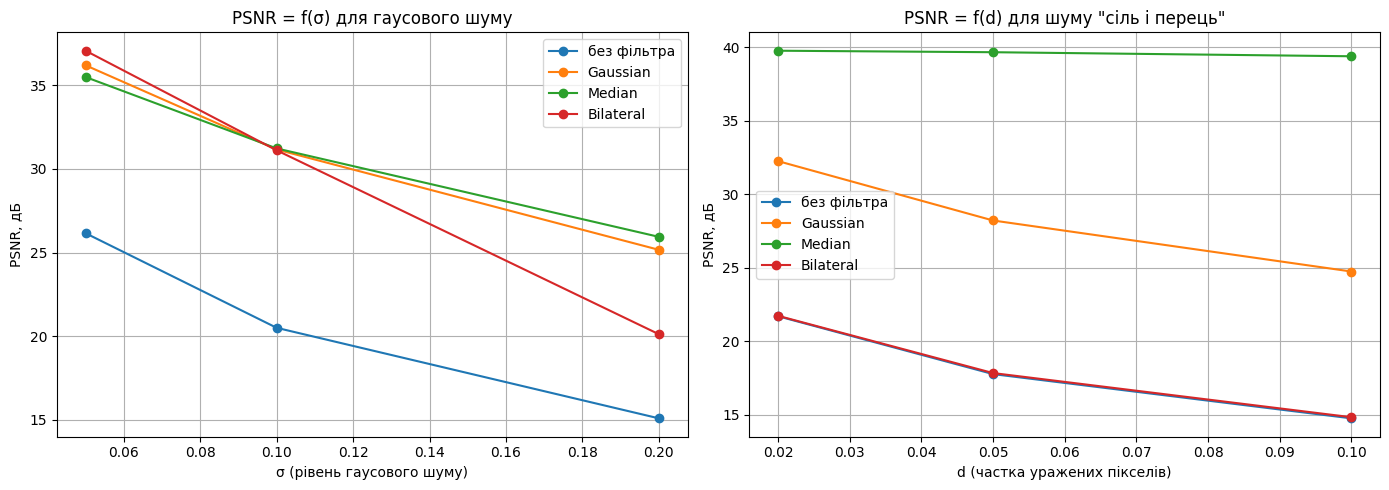

In [8]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for filt in filters:
    values = [row[3] for row in research_results if row[0] == "Гаусів" and row[2] == filt]
    plt.plot(sigma_levels, values, marker="o", label=filt)
plt.xlabel("σ (рівень гаусового шуму)")
plt.ylabel("PSNR, дБ")
plt.title("PSNR = f(σ) для гаусового шуму")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for filt in filters:
    values = [row[3] for row in research_results if row[0] == "Сіль-перець" and row[2] == filt]
    plt.plot(d_levels, values, marker="o", label=filt)
plt.xlabel("d (частка уражених пікселів)")
plt.ylabel("PSNR, дБ")
plt.title("PSNR = f(d) для шуму \"сіль і перець\"")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Висновки
• Який фільтр найкраще усуває Gaussian noise?  
Усі фільтри добре справляються з роботою, Bilateral трохи кращий для низького рівня шуму, тоді як Median і Gaussian - кращі для вищих.

• Який метод ефективніший для salt-and-pepper noise?  
Безперечний переможець - Median filter, Gaussian відпрацював помітно гірше, тоді як Bilateral не зміг нічого покращити.

• Як збільшення розміру ядра впливає на деталізацію?  
Збільшення ядра збільшує вплив сусідів - через це шуми краще прибираються, але разом з ними втрачаються й інші дрібні деталі.

• Чи завжди підвищення PSNR означає покращення візуальної якості?  
Не завжди, PSNR показує схожість пікселів, і не враховує наприклад структурну цілісність зображення як це робить SSIM, що можна сказати навіть важливіше.